# Chapter 3. SciPy

*   SciPy 패키지는 데이터 과학 등 과학적 계산에서 자주 발생하는 문제를 해결하기 위한 다양한 툴박스를 포함한다.
*   SciPy의 각 하위 모듈은 특수 함수(special functions), 통계(statistics), 보간법(interpolation), 최적화(optimization), 영상 처리(image processing) 등 서로 다른 응용 분야에 특화되어 있다.

SciPy는 파이썬에서 과학적 계산을 위한 핵심 패키지로, NumPy 배열(arrays)에 대하여 효율적으로 작동하도록 설계되어 있다.

어떤 데이터 분석 루틴을 구현하기 전에, 원하는 데이터 처리가 이미 SciPy에 구현되어 있는지를 확인하는 것이 좋다. 비전문 프로그래머들의 경우, 종종 기존에 있는 기능을 다시 구현하려는 경향이 있으며, 이는 오류가 많고 비효율적이며 공유 및 유지보수가 어려운 코드를 초래한다. 반면, SciPy의 루틴은 최적화되어 있고 테스트도 완료되어 있으므로 가능한 경우 이를 사용하는 것이 바람직하다.

SciPy는 작업별로 특화된 하위 모듈들로 구성되어 있다. 이들 모듈은 모두 NumPy에 의존하지만, 대부분 서로 독립적으로 작동한다. NumPy와 이러한 SciPy 모듈들을 불러오는 표준적인 방법은 다음과 같다:

In [1]:
import scipy as sp
import numpy as np

# 3.1. Special functions: `scipy.special`

"특수" 함수는 과학 및 수학에서 자주 사용되지만 "기초" 함수로는 간주되지 않는 함수들을 말한다. 예를 들어,

*   감마 함수: `scipy.special.gamma()`,
*   베셀 함수 (제1종 베셀 함수): `scipy.special.jv()`,
*   타원 함수 (자코비 타원 함수): `scipy.special.ellipj()`

등이 있다. 일부 특수 함수는 익숙한 기초 함수들의 조합으로 표현될 수 있지만, 단순한 구현 방식보다 더 높은 정확도나 안정성을 제공한다.

특수 함수들 대부분은 요소별(elementwise)로 계산되며, 입력 array들의 형태(shape)가 다른 경우에는 NumPy의 브로드캐스팅 규칙을 따른다.

예를 들어, `scipy.special.xlog1py()`는 수학적으로 $x \log(1 + y)$와 동일하다.

In [2]:
x = np.array([1, 2])
y = np.array([[3], [4], [5]])

In [3]:
x, y

(array([1, 2]),
 array([[3],
        [4],
        [5]]))

In [4]:
res = sp.special.xlog1py(x, y)
res, res.shape

(array([[1.38629436, 2.77258872],
        [1.60943791, 3.21887582],
        [1.79175947, 3.58351894]]),
 (3, 2))

In [5]:
ref = x * np.log(1 + y)
ref

array([[1.38629436, 2.77258872],
       [1.60943791, 3.21887582],
       [1.79175947, 3.58351894]])

In [6]:
np.allclose(res, ref)

True

그러나 `scipy.special.xlog1py()`는
$y$가 매우 작을 때 수치적으로 더 유리하다. 이 경우
`1+y`를 명시적으로 더하면 부동소수점 반올림 오차로 인해 정밀도가 손실될 수 있기 때문이다.

### 분모사용 llm 유의

In [8]:
x = 2.5
y = 1e-18
1 + y

1.0

In [10]:
x = 2.5
y = 1e-18
x * np.log(1 + y)

np.float64(0.0)

In [11]:
sp.special.xlog1py(x, y)

np.float64(2.5e-18)

많은 특수 함수들은 "로그 형태(logarithmized)"의 변형도 제공한다.

예를 들어, 감마 함수 $\Gamma(\cdot)$는 팩토리얼 함수와 $n! = \Gamma(n + 1)$의 관계를 가지며, 양의 정수에만 정의된 팩토리얼 함수의 정의역을 복소수 평면으로 확장한다.

In [12]:
x = np.arange(10)
sp.special.gamma(x + 1)

array([1.0000e+00, 1.0000e+00, 2.0000e+00, 6.0000e+00, 2.4000e+01,
       1.2000e+02, 7.2000e+02, 5.0400e+03, 4.0320e+04, 3.6288e+05])

In [13]:
sp.special.factorial(x)

array([1.0000e+00, 1.0000e+00, 2.0000e+00, 6.0000e+00, 2.4000e+01,
       1.2000e+02, 7.2000e+02, 5.0400e+03, 4.0320e+04, 3.6288e+05])

In [14]:
x = np.arange(10)
np.allclose(sp.special.gamma(x + 1), sp.special.factorial(x))

True

In [15]:
sp.special.gamma(5.5)

np.float64(52.34277778455352)

In [16]:
sp.special.gamma(5) < sp.special.gamma(5.5) < sp.special.gamma(6)

np.True_

팩토리얼 함수는 매우 빠르게 증가하기 때문에, 감마 함수는 비교적 작은 입력 값에서도 오버플로우(overflow)가 발생할 수 있다. 하지만 때로는 감마 함수의 로그값만 필요한 경우가 있으며, 이런 경우에는 `scipy.special.gammaln()`을 사용하여 감마 함수의 로그를 직접 계산할 수 있다.

In [20]:
x = [5, 50, 500]
sp.special.gamma(x)

array([2.40000000e+01, 6.08281864e+62,            inf])

In [19]:
np.log(sp.special.gamma(x))

array([  3.17805383, 144.56574395,          inf])

In [ ]:
sp.special.gammaln(x)  #inf 값이 나오는 것을 방지하기 위해 로그값을 계산하는 함수도 제공한다.

array([   3.17805383,  144.56574395, 2605.11585036])

이러한 로그 형태의 함수들은 계산 과정의 중간 단계에서 오버플로우(overflow)나 언더플로우(underflow)가 발생할 수 있지만, 최종 결과는 그렇지 않을 경우에 자주 사용될 수 있다. 예를 들어, $\Gamma(500)/\Gamma(499)$의 값을 계산하고자 하는 상황을 생각해보자.

In [22]:
a = sp.special.gamma(500)
b = sp.special.gamma(499)
a, b

(np.float64(inf), np.float64(inf))

분자와 분모 모두 오버플로우가 발생하기 때문에 $a/b$를 직접 계산하면 원하는 결과를 얻을 수 없다. 하지만 결과값 자체는 적당한 크기를 가지며 로그를 사용하여 이를 계산할 수 있다. 항등식 $\log(a/b)=\log(a)-\log(b)$와 $\exp(\log(x)) = x$를 결합하면 다음과 같은 계산이 가능하다.

In [23]:
log_a = sp.special.gammaln(500)
log_b = sp.special.gammaln(499)
log_a, log_b

(np.float64(2605.115850361734), np.float64(2598.9032442659823))

In [24]:
log_res = log_a - log_b
log_res

np.float64(6.212606095751653)

In [25]:
res = np.exp(log_res)
res

np.float64(499.00000000006696)

마찬가지로, $\log(\Gamma(500) - \Gamma(499))$를 계산하고자 할 때, `scipy.special.logsumexp()`를 사용할 수 있다. 이 함수는  오버플로우를 피하기 위한 수치적 기법을 사용하여 $\log(\exp(x)+\exp(y))$를 계산한다.









In [26]:
res = sp.special.logsumexp([log_a, log_b], b=[1, -1])    # weights the terms of the sum
res

np.float64(2605.1138443430073)

# 3.2. Linear algebra operations: `scipy.linalg`

`scipy.linalg`는 표준 선형대수 연산을 위한 효율적인 컴파일된 구현체인 BLAS(Basic Linear Algebra Subroutines)와 LAPACK(Linear Algebra PACKage) 라이브러리에 대한 파이썬 인터페이스를 제공한다.

예를 들어, `scipy.linalg.det()` 함수는 정방행렬(square matrix)의 행렬식(determinant)을 계산한다.

In [27]:
arr = np.array([[1, 2],
                [2, 3]])
arr

array([[1, 2],
       [2, 3]])

In [28]:
sp.linalg.det(arr)

np.float64(-1.0)

수학적으로 선형 방정식 $Ax = b$의 해는 $x = A^{-1}b$로 주어지지만, 주어진 행렬에 대하여 명시적으로 역행렬을 계산하는 것은 수치적으로 불안정하므로 피해야 한다. 대신 `scipy.linalg.solve()`를 사용하는 것이 좋다.

In [29]:
A = np.array([[1, 2],
              [2, 3]])
b = np.array([14, 23])
A, b

(array([[1, 2],
        [2, 3]]),
 array([14, 23]))

In [30]:
A_inv = sp.linalg.inv(A) # A의 역행렬을 계산한다. 역행렬은 A를 곱했을 때 단위 행렬이 되는 행렬이다
x = A_inv @ b
x

array([4., 5.])

In [31]:
x = sp.linalg.solve(A, b)
x

array([4., 5.])

In [32]:
np.allclose(A @ x, b)

True

특수한 구조를 가진 선형 방정식 시스템은 일반적인 경우보다 더 효율적으로 풀 수 있는 경우가 많다. 예를 들어, 삼각 행렬을 포함하는 선형 시스템은 `scipy.linalg.solve_triangular()`를 사용하여 해결할 수 있다.

In [33]:
A_upper = np.triu(A)
A_upper

array([[1, 2],
       [0, 3]])

In [34]:
x = sp.linalg.solve_triangular(A_upper, b, lower = False)
x

array([-1.33333333,  7.66666667])

In [35]:
np.allclose(x, sp.linalg.solve(A_upper, b))

True

In [36]:
%timeit sp.linalg.solve_triangular(A_upper, b, lower = False)
%timeit sp.linalg.solve(A_upper, b)

4.39 μs ± 13.7 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
9.29 μs ± 12.4 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


`scipy.linalg`는 특이값 분해(singular value decomposition)와 같은 행렬 분해 기능도 제공한다.

In [37]:
A = np.array([[1, 2],
              [2, 3]])
U, s, Vh = sp.linalg.svd(A)
U, s, Vh

(array([[-0.52573111, -0.85065081],
        [-0.85065081,  0.52573111]]),
 array([4.23606798, 0.23606798]),
 array([[-0.52573111, -0.85065081],
        [ 0.85065081, -0.52573111]]))

원래의 행렬은 분해된 행렬들을 행렬 곱으로 다시 곱하여 복원할 수 있다.

In [38]:
S = np.diag(s)
A2 = U @ S @ Vh
A2

array([[1., 2.],
       [2., 3.]])

In [39]:
A3 = (U * s) @ Vh
A3

array([[1., 2.],
       [2., 3.]])

In [40]:
%timeit A2 = U @ S @ Vh
%timeit A3 = (U * s) @ Vh

1.01 μs ± 26.2 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)
1.05 μs ± 23.2 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


`scipy.linalg`에는 LU·Cholesky·QR 분해와 같은 다양한 행렬 분해, 삼각·순환 행렬 등 구조화된 선형 시스템을 위한 해법, 고유값 문제 알고리즘, 행렬 지수와 같은 행렬 함수, 블록 대각·Toeplitz 행렬 등 특수 행렬의 생성 등 선형대수와 관련된 다양한 루틴들이 제공된다.

# 3.3. Interpolation: `scipy.interpolate`

`scipy.interpolate`는 실험이나 계산으로 얻은 데이터에 "보간 함수(interpolant)"를 적합하기 위해 사용된다. 보간 함수가 한번 적합되면, 이를 통해 중간 지점에서의 함수 값을 근사할 수 있고, 함수의 적분, 도함수, 또는 역함수도 계산할 수 있다.

“스무딩 스플라인(smoothing splines)”이라 불리는 특정 종류의 보간 함수는 노이즈가 포함된 데이터로부터 부드러운(smooth) 곡선을 생성하도록 설계되어 있다. 예를 들어, 다음과 같은 데이터가 있다고 가정해보자.

In [41]:
rng = np.random.default_rng(27446968)
measured_time = np.linspace(0, 2*np.pi, 20)
function = np.sin(measured_time)
noise = rng.normal(loc = 0, scale = 0.1, size = 20)
measurements = function + noise

In [42]:
import matplotlib.pyplot as plt
%matplotlib inline

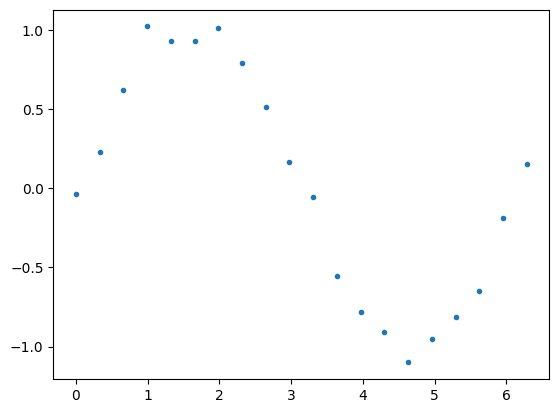

In [43]:
plt.plot(measured_time, measurements, ".", ms=6, label="measurements")

`scipy.interpolate.make_smoothing_spline()`을 사용하면, 데이터 생성에 가정된 사인(sin) 함수를 근사하는 곡선을 생성할 수 있다.

In [48]:
smoothing_spline =sp.interpolate.make_smoothing_spline(measured_time, measurements)

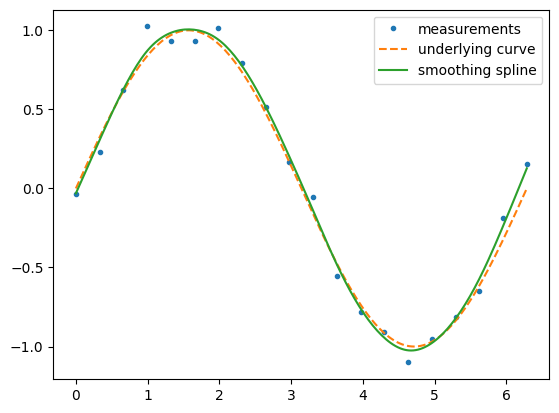

In [45]:
plt.plot(measured_time, measurements, ".", ms=6, label="measurements")
interpolation_time = np.linspace( 0, 2*np.pi, 200)
smooth_results = smoothing_spline(interpolation_time)
plt.plot(interpolation_time, np.sin(interpolation_time), "--", label="underlying curve")
plt.plot(interpolation_time, smooth_results, label="smoothing spline")
plt.legend()
plt.show()

만약 데이터에 잡음(noise)이 없다면 각 점을 정확히 통과하는 보간이 바람직할 수 있다.

In [46]:
interp_spline = sp.interpolate.make_interp_spline(measured_time, function)
interp_results = interp_spline(interpolation_time)

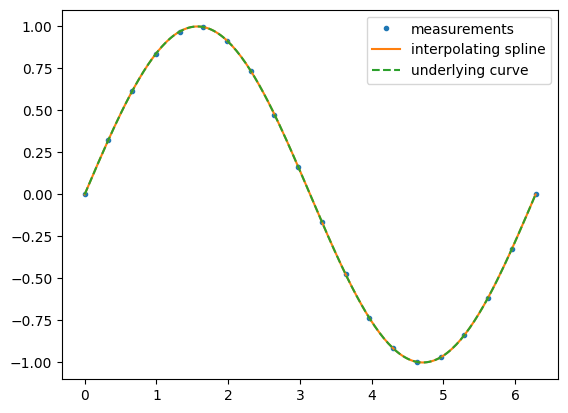

In [47]:
plt.plot(measured_time, function, ".", ms=6, label="measurements")
plt.plot(interpolation_time, interp_results, label="interpolating spline")
plt.plot(interpolation_time, np.sin(interpolation_time), "--", label="underlying curve")
plt.legend()

결과 객체의 `derivative`와 `antiderivative` 메서드를 사용하여 미분과 적분을 수행할 수 있다. 적분의 경우, 적분 상수는 기본적으로 0으로 가정되지만, 적분 결과를 "감싸서(wrap)" 적분 상수가 0이 아닌 값을 포함하도록 만들 수도 있다.

In [49]:
d_interp_spline = interp_spline.derivative()
d_interp_spline(4.5)

array(-0.21095382)

In [50]:
i_interp_spline = lambda t: interp_spline.antiderivative()(t)
i_interp_spline(np.pi)

array(1.99998511)

In [1]:
import scipy as sp 
import numpy as np

In [5]:
import matplotlib.pyplot as plt

# 3.4. Optimization and fit: `scipy.optimize`

`scipy.optimize`는 근 찾기(root finding), 곡선 적합(curve fitting), 그리고 보다 일반적인 최적화 문제를 해결하기 위한 알고리즘들을 제공한다.

## 3.4.1. Root finding

`scipy.optimize.root_scalar()`는 주어진 scalar 값 함수의 근(즉, 함수 값이 0이 되는 입력값)을 찾는다.  
다른 많은 `scipy.optimize` 함수들과 마찬가지로, 이 함수도 해에 대한 초기 추정값이 필요하며,   
알고리즘은 이를 반복적으로 개선하여 수렴하거나 실패를 인식할 때까지 수행된다.  
수렴 속도를 향상시키기 위해 주어진 scalar 값 함수의 도함수를 함께 제공할 수도 있다.









In [2]:
def f(x):
    return (x - 1) * (x - 2)
x0 = 0  # guess
res = sp.optimize.root_scalar(f, x0 = x0)
res

      converged: True
           flag: converged
 function_calls: 12
     iterations: 6
           root: 1.0
         method: newton

In [3]:
def df(x):
    return 2*x - 3
res = sp.optimize.root_scalar(f, x0 = x0, fprime = df)
res

      converged: True
           flag: converged
 function_calls: 12
     iterations: 6
           root: 1.0
         method: newton

1.0에서의 근만 찾아졌다는 점에 주의해야 한다. 주어진 함수를 살펴보면, 2.0에서도 또 다른 근이 있다는 것을 알 수 있다. 초기 추정값을 변경하거나, 찾고자 하는 근만 포함하는 구간(bracket)을 지정함으로써 원하는 근을 향해 함수가 수렴하도록 유도할 수 있다.

In [4]:
res = sp.optimize.root_scalar(f, bracket = (1.5, 10))
res

      converged: True
           flag: converged
 function_calls: 15
     iterations: 14
           root: 2.0
         method: brentq

다변수 문제의 경우, `scipy.optimize.root()`를 사용한다.

In [ ]:
def f(x):
    # intersection of unit circle and line from origin
    return [x[0]**2 + x[1]**2 - 1,
            x[1] - x[0]]
res = sp.optimize.root(f, x0 = (0, 0))

In [ ]:
res.x, np.allclose(res.x, np.sqrt(2)/2)

In [ ]:
f(res.x)
np.allclose(f(res.x), 0)

## 3.4.2. Curve fitting

사인(sin) 형태이지만 잡음이 섞인 데이터를 가지고 있다고 가정하자.

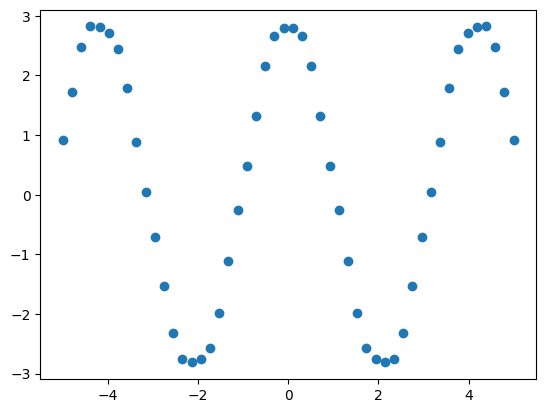

In [6]:
x = np.linspace(-5, 5, num=50)    # 50 values between -5 and 5
noise = 0.1 * np.cos(100 * x)
a, b = 2.9, 1.5
y = a * np.cos(b * x) + noise
plt.scatter(x, y)

최소제곱 방법(least squares method)을 통해 데이터로부터 기저의 진폭(amplitude), 주파수(frequency), 위상(phase)을 추정할 수 있다.  
먼저, 독립 변수를 첫 번째 인자로 받고, 적합할 모든 매개변수를 개별 인자로 받는 함수를 작성한다.

In [7]:
def f(x, a, b, c):
    return a * np.sin(b * x + c)

`scipy.optimize.curve_fit()`을 사용하여 데이터로부터 매개변수들을 추정한다.

In [8]:
params, _ = sp.optimize.curve_fit(f, x, y, p0 = [2, 1, 3])
params

array([2.90027637, 1.50120365, 1.57079633])

##### 공분산행렬은 사용하지 않으므로 _ 로 표기함

노이즈 적은 데이터  →  pcov 작음  →  파라미터 신뢰도 높음   
노이즈 많은 데이터  →  pcov 큼   →  파라미터 신뢰도 낮음 

신뢰구간  
perr = np.sqrt(np.diag(pcov))  # 표준오차  
# 95% 신뢰구간  
params ± 1.96 * perr  
  
perr / params  →  상대 오차 (%)  
a = 2.9,  perr = 0.03  →  상대오차 ≈ 1%   ✓ 신뢰 가능  
b = 1.5,  perr = 0.8   →  상대오차 ≈ 53%  ✗ 신뢰 어려움  

In [9]:
ref = [a, b, np.pi/2]    # what we'd expect
ref, np.allclose(params, ref, rtol=1e-3)

([2.9, 1.5, 1.5707963267948966], True)

## 3.4.4. Optimization

scalar 값의 단일 변수(univariate) 함수 $f(x) = x^2 + 10\sin(x)$를 최소화하고자 한다고 가정하자.

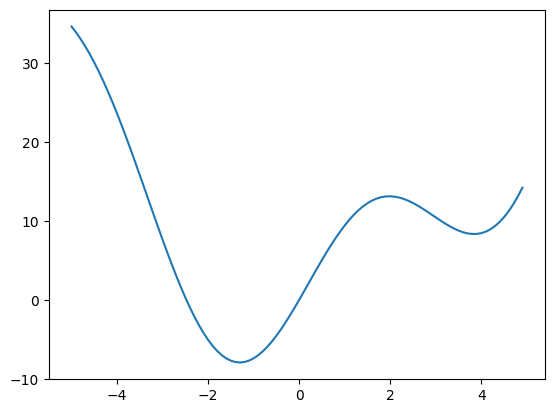

In [10]:
def f(x):
    return x ** 2 + 10 * np.sin(x)
x = np.arange(-5, 5, 0.1)
plt.plot(x, f(x))

이 함수는 $x = 3.8$ 근처에 국소 최소값(local minimum)을, $x = -1.3$ 근처에 전역 최소값(global minimum)을 가지는 것으로 보이지만, 정확한 값은 그래프만으로는 알 수 없다.

이러한 목적에 가장 적합한 함수는 `scipy.optimize.minimize_scalar()`이다. 최소값의 대략적인 위치를 알고 있으므로, 전역 최소값 근처로 탐색 범위를 제한하기 위해 경계(bounds)를 지정한다.

In [11]:
res = sp.optimize.minimize_scalar(f, bounds=(-2, -1))
res

 message: Solution found.
 success: True
  status: 0
     fun: -7.9458233756095895
       x: -1.3064409970312618
     nit: 8
    nfev: 8

fun : function 값

In [12]:
res.x, res.fun

(np.float64(-1.3064409970312618), np.float64(-7.9458233756095895))

### 다변수 최적화 문제의 경우, `scipy.optimize.minimize()`가 좋은 선택이 된다.  
예를 들어, 두 변수에 대한 이차 함수 $f(x_0, x_1) = (x_0 - 1)^2 + (x_1 - 2)^2$의 최소값을 찾아보자.

In [13]:
def f(x):
    return (x[0] - 1) ** 2 + (x[1] - 2) ** 2

`scipy.optimize.root()`와 마찬가지로, `scipy.optimize.minimize()`도 초기 추정값 `x0`를 필요로 한다.

In [15]:
res = sp.optimize.minimize(f, x0 = [0, 0]) # 초기추정값 
res

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 1.705780445775116e-16
        x: [ 1.000e+00  2.000e+00]
      nit: 2
      jac: [ 3.219e-09 -8.462e-09]
 hess_inv: [[ 9.000e-01 -2.000e-01]
            [-2.000e-01  6.000e-01]]
     nfev: 9
     njev: 3

**`scipy.optimize.minimize()`는 최소화 문제에만 사용될까? 아니다! 최대화 문제를 해결하려면, 원래 목적 함수에 음수를 곱한 함수를 최소화하면 된다.**

## Exercise: Curve fitting of temperature data

알래스카의 각 월별 최고 및 최저 기온은 1월부터 시작하여 다음과 같다 (섭씨 기준):



```
max:  17,  19,  21,  28,  33,  38, 37,  37,  31,  23,  19,  18
min: -62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58
```



1.  각 월별 최고 및 최저 기온을 그래프로 나타내시오.
2.  최소 및 최대 기온을 설명할 수 있는 함수를 정의하시오. 이 함수는 1년의 주기를 가져야 하며 시간 오프셋(time offset)을 포함해야 한다.
3.  `scipy.optimize.curve_fit()`을 사용하여 위에서 정의한 함수를 데이터에 적합시키시오.
4.  적합 결과를 그래프로 나타내시오.



In [16]:
temp_max = np.array([17,  19,  21,  28,  33,  38, 37,  37,  31,  23,  19,  18])
temp_min = np.array([-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58])
month = np.arange(1, 13)

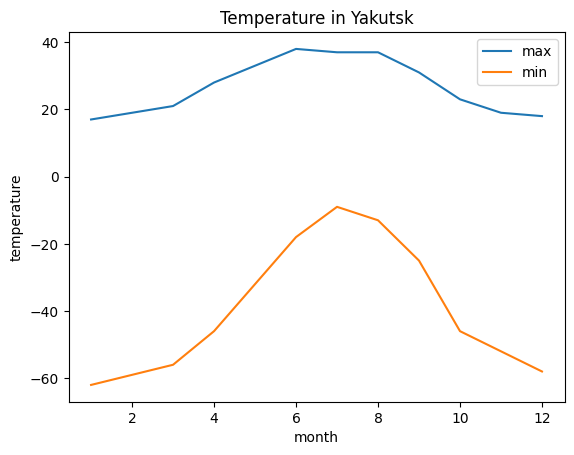

In [17]:
#1.  각 월별 최고 및 최저 기온을 그래프로 나타내시오.
plt.plot(month, temp_max, label="max")
plt.plot(month, temp_min, label="min")
plt.xlabel("month")
plt.ylabel("temperature")
plt.title("Temperature in Yakutsk")
plt.legend()
plt.show()

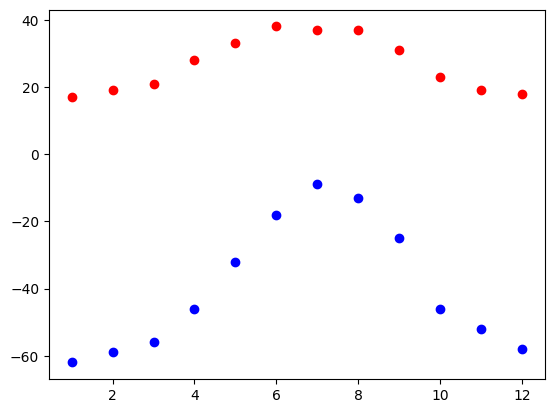

In [18]:
plt.plot(month, temp_max, 'ro', month, temp_min, 'bo')

In [20]:
#2.  최소 및 최대 기온을 설명할 수 있는 함수를 정의하시오. 이 함수는 1년의 주기를 가져야 하며 시간 오프셋(time offset)을 포함해야 한다.

def monthly_temps(time, avg, ampl, time_offset):
    return avg + ampl * np.cos((time + time_offset) * 2 * np.pi / 12)

In [21]:
#3.  `scipy.optimize.curve_fit()`을 사용하여 위에서 정의한 함수를 데이터에 적합시키시오.
params, _ = sp.optimize.curve_fit(monthly_temps, month, temp_max, p0 = [10, 20, 0])
params, np.allclose(params, [20.5, 19.5, 1.0], rtol=1e-2)   

(array([ 26.75      , -10.93254952,  -0.72348005]), False)

In [ ]:
# 교수님 
res_max, _ = sp.optimize.curve_fit(monthly_temps, month, temp_max , p0 = [30, 20, 0]) #20 
print(res_max)

[ 26.75       -10.93254953  -0.72348004]


In [26]:
res_min, _ = sp.optimize.curve_fit(monthly_temps, month, temp_min , p0 = [-40, 50, 0]) # avg -40, 진폭, time_offset 
print(res_min)

[-39.66666666 -25.58169519  -1.15603649]


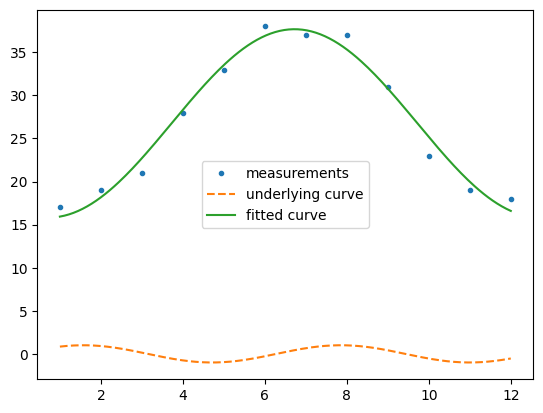

In [23]:
#4.  적합 결과를 그래프로 나타내시오.
plt.plot(month, temp_max, ".", ms=6, label="measurements")
interpolation_time = np.linspace(1, 12, 200)
smooth_results = monthly_temps(interpolation_time, *params)
plt.plot(interpolation_time, np.sin(interpolation_time), "--", label="underlying curve")
plt.plot(interpolation_time, smooth_results, label="fitted curve")
plt.legend()
plt.show()


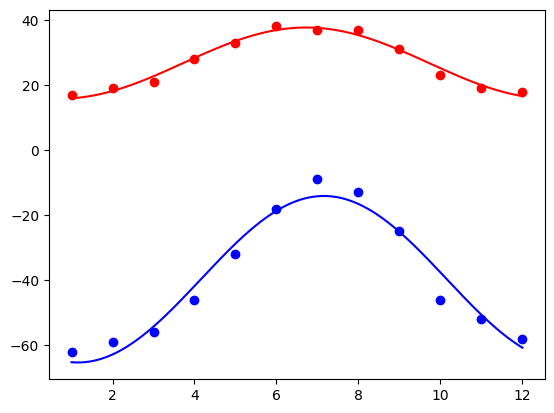

In [ ]:
plt.plot(month, temp_max, 'ro', month, temp_min, 'bo')
grid = np.linspace(1,12,400)
plt.plot(grid, monthly_temps(grid, *res_max), 'r-'). 
# * 들어가는 이유 : res_max이 리스트 형태로 되어있기 때문에, 리스트의 요소들을 monthly_temps 함수의 인자로 전달하기 위해서 *를 사용한다.
plt.plot(grid, monthly_temps(grid, *res_min), 'b-')


# 3.5. Statistics and random numbers: `scipy.stats`

`scipy.stats`는 파이썬에서 통계 분석을 위한 기본적인 도구들을 포함하고 있다.

## 3.5.1. Statistical distributions

표준 정규 분포를 따르는 확률 변수를 상정하고, 이 확률 변수로부터 100,000개의 관측값을 샘플링한다고 가정하자. 이렇게 얻은 표본(sample)의 정규화된 히스토그램은 해당 확률 변수의 확률 밀도 함수(probability density function)를 추정한 것이다.

In [51]:
dist = sp.stats.norm(loc = 0, scale = 1)    # standard normal distribution
sample = dist.rvs(size = 100000)            # generate 100,000 random numbers

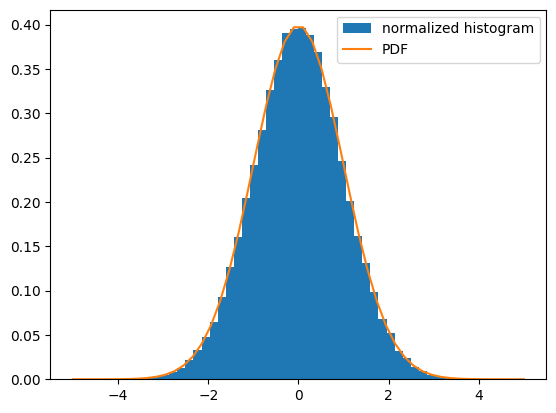

In [52]:
plt.hist(sample, bins = 50, density = True, label = 'normalized histogram')
x = np.linspace(-5, 5)
plt.plot(x, dist.pdf(x), label='PDF')
plt.legend()

주어진 표본이 정규 분포 계열의 어떤 분포에서 추출되었음은 알고 있지만, 그 분포의 모평균과 모표준편차는 모른다고 가정하자. 이러한 미지의 모수를 최대우도추정(maximum likelihood estimation) 방식으로 추정하기 위해, 해당 분포의 `fit` 메서드를 사용한다.

In [53]:
loc, scale = sp.stats.norm.fit(sample)
loc, scale

(np.float64(-0.00010431847128848162), np.float64(0.9977907168701966))

## 3.5.2. Sample statistics and hypothesis tests

표본 평균은 표본이 추출된 분포의 평균에 대한 추정값이다.

In [54]:
np.mean(sample)

np.float64(-0.00010431847128848162)

NumPy는 `numpy.mean(), numpy.var(), numpy.percentile()`과 같은 가장 기본적인 표본 통계량들을 포함하고 있으며, `scipy.stats`는 이보다 훨씬 더 다양한 통계량을 제공한다. 예를 들어, 기하 평균(geometric mean)은 값의 크기가 여러 자릿수 범위에 걸쳐 분포하는 데이터에서 중심 경향을 나타내는 데 자주 사용되는 통계량이다.

np.float64(0.9998854010124731)

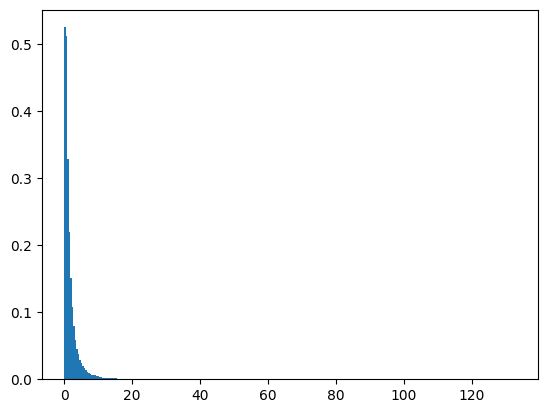

In [55]:
plt.hist(3**sample, bins = 300, density = True, label = 'normalized histogram')
sp.stats.gmean(3**sample)

SciPy는 검정 통계량과 p-value를 제공하는 다양한 통계적 가설 검정들을 지원한다. 예를 들어, 주어진 데이터가 정규 분포에서 추출되었는지를 확인하기 위한 가설 검정을 수행한다고 가정해보자.

In [56]:
res = sp.stats.normaltest(sample)
res.statistic, res.pvalue

(np.float64(1.8648818516427186), np.float64(0.39359180847522396))

여기서 statistic은 정규분포가 아닌 분포에서 추출된 표본일수록 높은 값을 가지는 검정 통계량이다. p-value는 정규분포에서 추출된 표본이 이처럼 큰 통계량 값을 가질 확률을 의미한다. 만약 p-value가 매우 작다면, 해당 표본이 정규분포에서 추출되지 않았다는 증거로 해석될 수 있다.

In [58]:
sp.stats.ttest_1samp(sample, popmean = 0)

TtestResult(statistic=np.float64(-0.03306127390213197), pvalue=np.float64(0.9736257907888628), df=np.int64(99999))

## Exercise: Probability distributions

shape parameter가 2, scale parameter가 1인 감마 분포(gamma distribution)에서 난수 1000개를 생성하시오.

1.  생성한 표본의 히스토그램을 그리고, 그 위에 감마 분포의 확률 밀도 함수를 겹쳐서 나타내시오.
2.  `fit` 메서드를 사용하여 생성된 표본으로부터 감마 분포의 모수를 추정하시오.


In [59]:
sp.stats.gamma?

Signature:       sp.stats.gamma(*args, **kwds)
Type:            gamma_gen
String form:     <scipy.stats._continuous_distns.gamma_gen object at 0x116e28980>
File:            /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py
Docstring:      
A gamma continuous random variable.

As an instance of the `rv_continuous` class, `gamma` object inherits from it
a collection of generic methods (see below for the full list),
and completes them with details specific for this particular distribution.

Methods
-------
rvs(a, loc=0, scale=1, size=1, random_state=None)
    Random variates.
pdf(x, a, loc=0, scale=1)
    Probability density function.
logpdf(x, a, loc=0, scale=1)
    Log of the probability density function.
cdf(x, a, loc=0, scale=1)
    Cumulative distribution function.
logcdf(x, a, loc=0, scale=1)
    Log of the cumulative distribution function.
sf(x, a, loc=0, scale=1)
    Survival function  (also defined as ``1 - cdf``, bu

In [ ]:
#2 
a, log, scale = sp.stats.gamma.fit(sample)


In [62]:
a, log, scale

(np.float64(143142.39101317694),
 np.float64(-377.5190019439116),
 np.float64(0.0026373660974444444))